In [5]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

  Activating project at `~/projects/EccentricBurstTimings`


In [6]:
using EccentricBurstTiming, CairoMakie, CSV, DataFrames, QuadGK
# using Unitful, UnitfulAstro
defaulttheme = Theme(Axis = (xgridvisible=false, ygridvisible=false,
                            yminorticks=IntervalsBetween(4),
                            xminorticks=IntervalsBetween(4),
                            yminorticksvisible=true,
                            xminorticksvisible=true,
                            titlefont = :regular,
                            xminorticksize=3,
                            yminorticksize=3,
                            ylabelsize=20,
                            xlabelsize=20
                            ),
                    Legend = (framevisible=false,),
                    size=(800, 600))
set_theme!(defaulttheme)
update_theme!(theme_latexfonts())

const EBT = EccentricBurstTiming
const DATADIR = joinpath(@__DIR__, "..", "data")

"/home/cwbruenech/projects/EccentricBurstTimings/notebooks/../data"

In [7]:
let b = BurstTimingModel(m12 = 40, a0=0.1, e0=0.99)
    P = 2π/√b.m₁₂ * √((b.p₀/(1 - b.e₀^2))^3)
    println(P * b.m₁₂ * EBT.Constants.Msolsec)
    println(orbital_period_s(0.1, 28.94427190999916, 11.05572809000084))
    println(EBT.get_masses(b))
end

7.89331502638534
50.04112453852489
(28.94427190999916, 11.05572809000084)


In [8]:
G_solar = 3.9413556368747037e-7 # R⊙^3 s^-2 M⊙^-1
c_solar = 0.4309220324852666 # R⊙/s

function get_unperturbed_model(;args...)
    args = copy(args)

    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end
    args[:m3] = 0.0

    return  BurstTimingModel(;args...)
end

function get_perturbed_model(;args...)
    args = copy(args)
    
    if haskey(args, :m1)
        pop!(args, :m1)
    end

    if haskey(args, :m2)
        pop!(args, :m2)
    end

    return  BurstTimingModel(;args...)
end

function get_models(;args...)

    m = get_unperturbed_model(;args...)
    m_p =  get_perturbed_model(;args...)
    
    return m, m_p
end

function decay_time_s(a0, e0, m1, m2)
    G³ = G_solar^3
    c⁵ = c_solar^5

    β = 64/5*(G³*m1*m2*(m1 + m2))/c⁵
    c0 = a0*(1 - e0^2)/(e0^(12/19))*(1 + 121/304*e0^2)^(-870/2299)
    integral(e) = (e^(29/19)*(1 + (121/304)*e^2)^(1181/2299))/sqrt(1 - e^2)^3

    int, err = quadgk(integral, 0, e0)

    T = 12/19*c0^4/β*int
    return T
end

function orbital_period_s(a, m1, m2)
    return 2π*sqrt(a^3/(G_solar*(m1 + m2)))
end

orbital_period_s (generic function with 1 method)

In [9]:
function get_kummer_models(filename="GW_advanced_high_density_Z0005.csv"; e_min=0.1)
    filepath = joinpath(DATADIR, "kummer2024", "data_models", filename)
    @assert isfile(filepath) "File $filename not found."

    params = Dict{Int, Dict{Symbol, Float64}}()

    rows = CSV.Rows(filepath)
    for (i, row) in enumerate(rows)
        !iszero(i%2) && continue
        parse(Bool, lowercase(row.merger)) && continue
        e0 = parse(Float64, row.e_in)
        (e0 < e_min) && continue
        a0 = parse(Float64, row.a_in)
        m1, m2 = parse.(Float64, (row.m1, row.m2))
        m12 = m1 + m2
        eta = (m1*m2)/m12/m12
        i0 = parse(Float64, row.incl)
        
        R3 = parse(Float64, row.a_out)
        m3 = parse(Float64, row.m3)
        e3 = parse(Float64, row.e_out)

        ID = parse(Int, row.ID)

        params[ID] = Dict(:e0 => e0, :a0 => a0, :m12 => m12, :m1 => m1, :m2 => m2,
                          :eta => eta, :i0 => i0, :R3 => R3, :m3 => m3, :e3 => e3)
    end

    return params
end

function get_bruenech_models(filename="triple-induced-mergers.csv"; e_min=0.1)
    filepath = joinpath(DATADIR, "triple_bhbs", filename)
    @assert isfile(filepath) "File $filename not found."

    params = Dict{Int, Dict{Symbol, Float64}}()

    rows = CSV.Rows(filepath)
    for (i, row) in enumerate(rows)
        e0 = parse(Float64, row.e_in)
        (e0 < e_min) && continue
        a0 = parse(Float64, row.a_in)
        m1, m2 = parse.(Float64, (row.m1, row.m2))
        m12 = m1 + m2
        eta = (m1*m2)/m12/m12
        i0 = parse(Float64, row.i_mut)
        
        R3 = parse(Float64, row.a_out)
        R3 < zero(R3) && continue
        m3 = parse(Float64, row.m3)
        e3 = parse(Float64, row.e_out)

        ID = parse(Int, row.ID)

        params[ID] = Dict(:e0 => e0, :a0 => a0, :m12 => m12, :m1 => m1, :m2 => m2,
                          :eta => eta, :i0 => i0, :R3 => R3, :m3 => m3, :e3 => e3)
    end

    return params
end

get_bruenech_models (generic function with 2 methods)

## Example

┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:194


388145


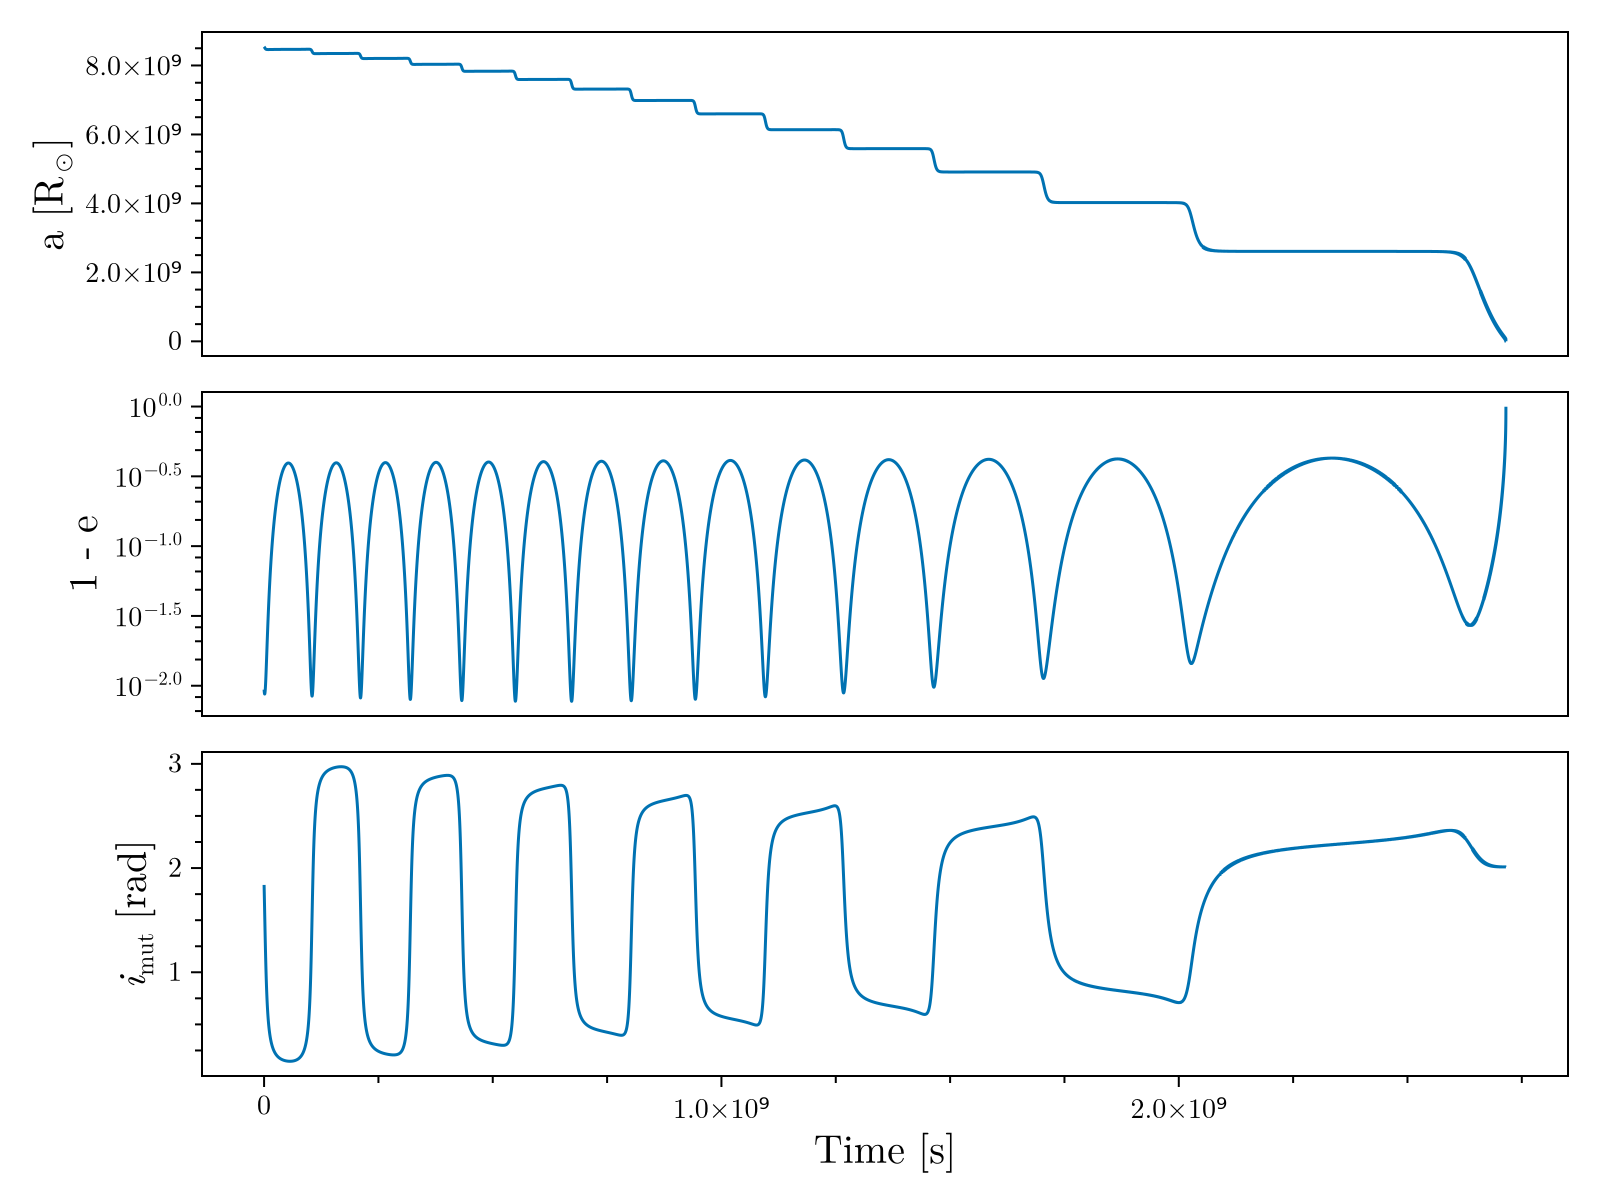

In [10]:
let models = get_kummer_models(e_min=0.7)
    
    IDs = collect(keys(models))
    
    params = models[IDs[2]]
    m = get_perturbed_model(;params...)
    # println(EBT.peak_f_GW(m, 1))
    evolve!(m, 1_000_000, f_GW_max=10, e_min=0.001, verbose=true)
    N = length(m.t)
    println(N)

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]")
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=log10)
    ax_i = Axis(fig[3, 1], ylabel=L"$i_\text{mut}$ [rad]", xlabel="Time [s]")

    hidexdecorations!(ax)
    hidexdecorations!(ax_e)
    linkxaxes!(ax, ax_e, ax_i)

    t = get_t_array(m, N)
    a = get_a_array(m, N)
    e = get_e_array(m, N)
    i = EBT.get_i_array(m, N)

    lines!(ax, t, a)
    lines!(ax_e, t, 1 .- e)
    lines!(ax_i, t, i)
    fig
end

0.07386394541251286


┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:194


9568


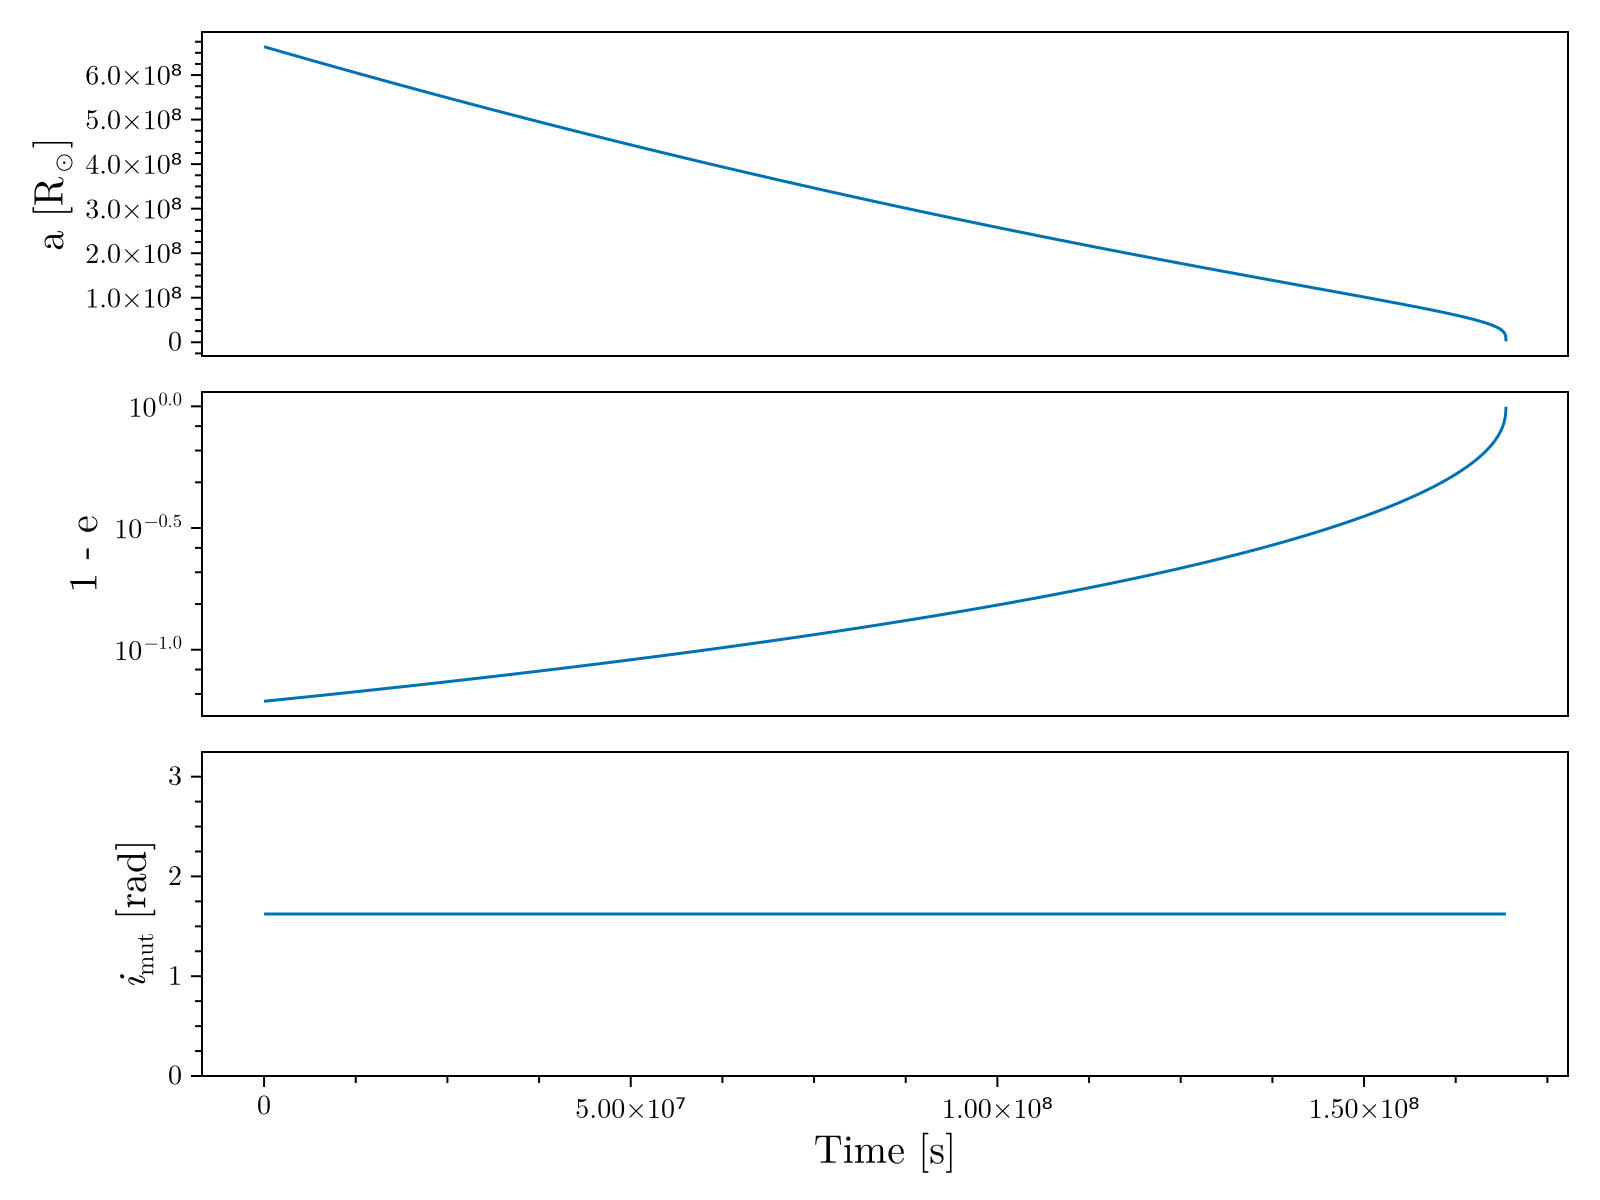

In [ ]:
let models = get_bruenech_models()#get_kummer_models(e_min=0.1)
    
    IDs = collect(keys(models))
    

    params = models[IDs[1]]
    m = get_unperturbed_model(;params...)
    println(EBT.peak_f_GW(m, 1))
    t_decay_s = decay_time_s(params[:a0], params[:e0], params[:m1], params[:m2])
    period_s = orbital_period_s(params[:a0], params[:m1], params[:m2])
    T = t_decay_s/period_s

    evolve!(m, 10_000_000, f_GW_max=10, e_min=0.001, verbose=true, fGW_saving_threshold=1e-4, save_params=false, save_every=100)
    N = length(m.t)
    println(N)

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]")
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=log10)
    ax_i = Axis(fig[3, 1], ylabel=L"$i_\text{mut}$ [rad]", xlabel="Time [s]")

    hidexdecorations!(ax)
    hidexdecorations!(ax_e)
    linkxaxes!(ax, ax_e, ax_i)

    t = get_t_array(m, N)
    a = get_a_array(m, N)
    e = get_e_array(m, N)
    i = EBT.get_i_array(m, N)

    lines!(ax, t, a)
    lines!(ax_e, t, 1 .- e)
    lines!(ax_i, t, i)
    fig
end

┌ Info: Stopping condition: fGW > fGW_max
└ @ EccentricBurstTiming /home/cwbruenech/projects/EccentricBurstTimings/src/EccentricBurstTiming.jl/src/EccentricBurstTiming.jl:183


95676


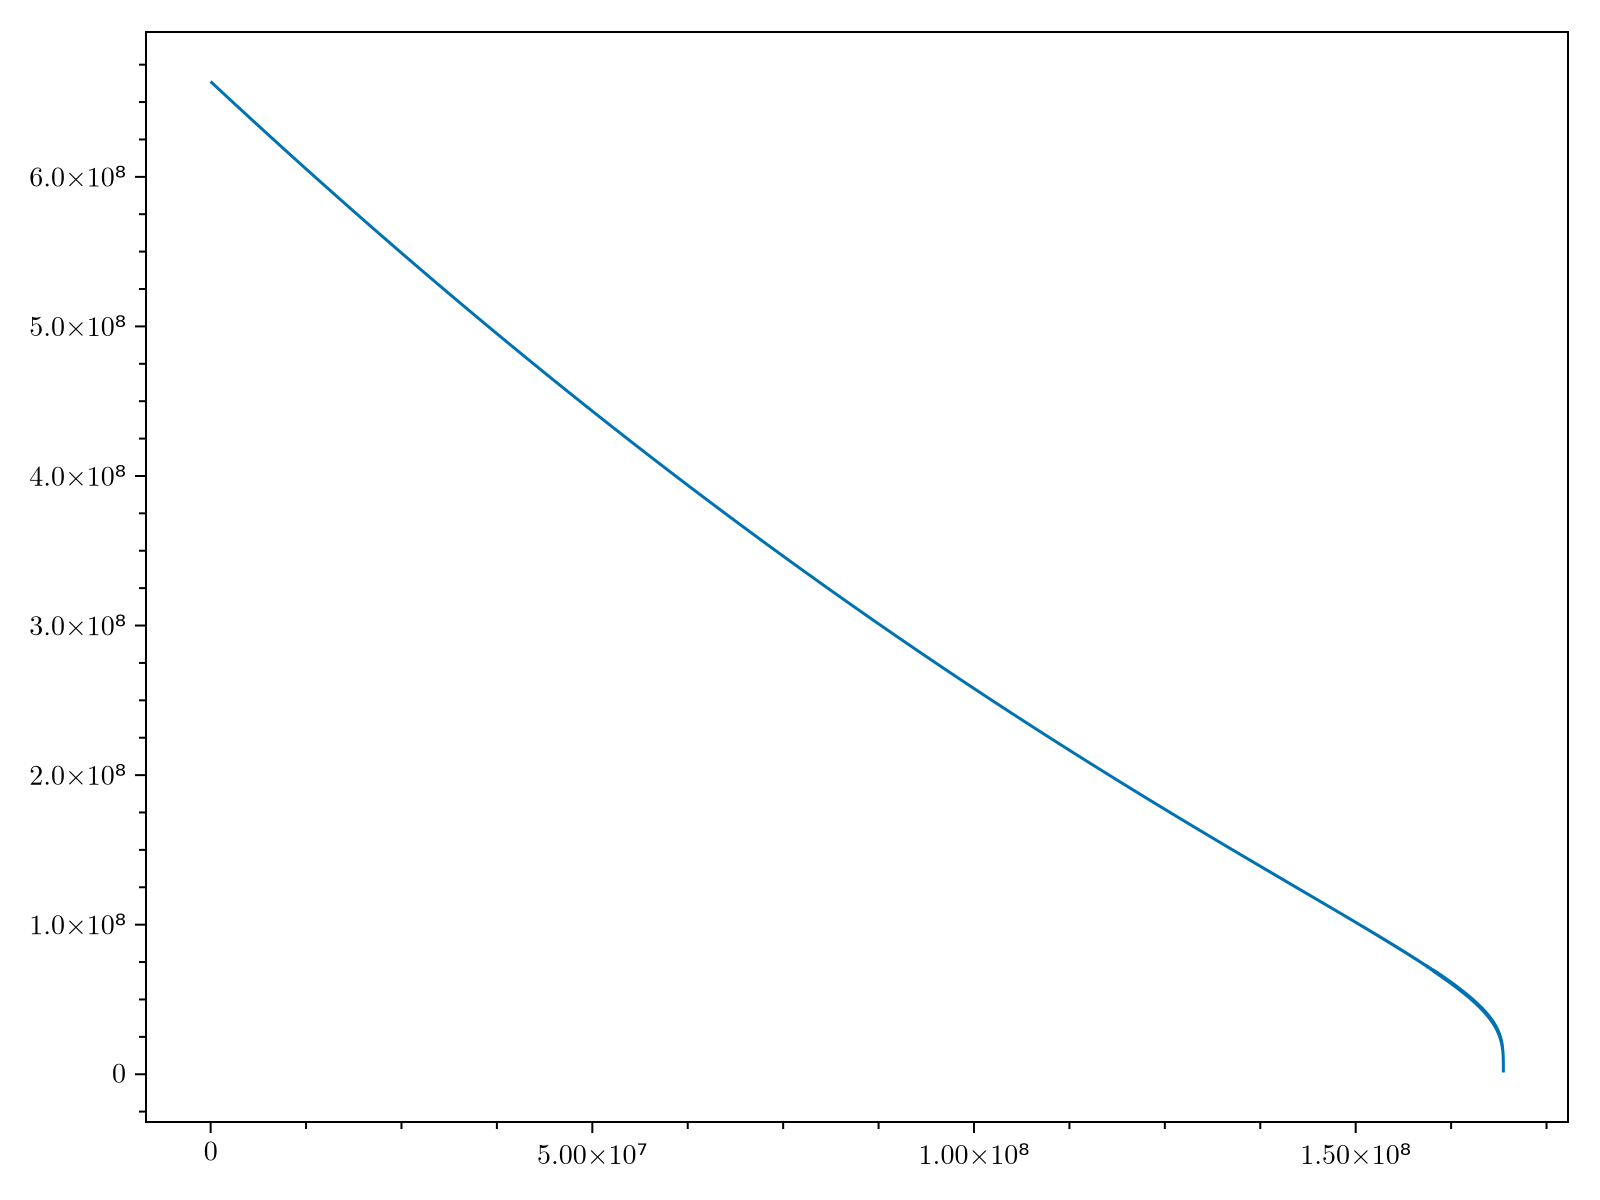

In [78]:
let
    ms = get_bruenech_models()
    IDs = collect(keys(ms))
    
    params = ms[IDs[1]]
    m = get_perturbed_model(;params...)
    evolve!(m, 1_000_000, f_GW_max=20, e_min=0.001, verbose=true, fGW_saving_threshold=1e-3, save_params=false, save_every=10)
    N = length(m.t)
    println(N)

    fig = Figure()
    ax = Axis(fig[1, 1])

    t = get_t_array(m, N)
    a = get_a_array(m, N)
    lines!(ax, t, a)
    fig
end

In [17]:
function get_header_arrays(model, N)
    e_array = EBT.get_e_array(model, N)
    a_array = EBT.get_a_array(model, N)
    t_array = EBT.get_t_array(model, N)
    w_array = EBT.get_w_array(model, N)
    V3_array = EBT.get_V3_array(model, N)

    W_array = EBT.get_W_array(model, N)
    i_array = EBT.get_i_array(model, N)

    return e_array, a_array, t_array, w_array, V3_array, W_array, i_array
end


function evolve_and_save_models(filename, model_data; e_min=0.7, perturbed_params=Dict(), unperturbed_params=Dict())

    output_dir = replace(joinpath(DATADIR, "evolution", filename), ".csv" => "")
    !isdir(output_dir) && mkdir(output_dir)
    
    lck = ReentrantLock()
    models = model_data(filename, e_min=e_min)

    IDs = collect(keys(models))
    header = ["time_s", "a_m", "e", "w", "iota", "W", "V3", "fGW"]
    n_bursts_up = pop!(unperturbed_params, :n_bursts, 1_000_000)
    n_bursts_pert = pop!(perturbed_params, :n_bursts, 1_000_000)
    Threads.@threads for ID in IDs
        params = models[ID]
        t_decay_s = decay_time_s(params[:a0], params[:e0], params[:m1], params[:m2])
        period_s = orbital_period_s(params[:a0], params[:m1], params[:m2])
        if t_decay_s/period_s > 1e6
            continue
        end
        m, m_pert = get_models(;params...)
        
        outfile = joinpath(output_dir, "$ID.csv")
        let model = m
            evolve!(model, n_bursts_up, f_GW_max=20, e_min=0.001; unperturbed_params...)
            N = length(model.t)
            success = EBT.peak_f_GW(model, length(model.t)) > 8


            e, a, t, w, V3, W, i = get_header_arrays(model, N)
            fGWs = map(x -> EBT.peak_f_GW(model, x), 1:N)
            CSV.write(outfile, Tables.table([t a e w i W V3 fGWs]), header=header)
        end

        let model = m_pert
            evolve!(model, n_bursts_pert, f_GW_max=20, e_min=0.001; perturbed_params...)
            N = length(model.t)
            success = EBT.peak_f_GW(model, length(model.t)) > 8

            outfile = replace(outfile, ".csv" => "_pert.csv")

            e, a, t, w, V3, W, i = get_header_arrays(model, N)
            fGWs = map(x -> EBT.peak_f_GW(model, x), 1:N)
            CSV.write(outfile, Tables.table([t a e w i W V3 fGWs]), header=header)

        end
    end
end

evolve_and_save_models (generic function with 1 method)

In [15]:
evolve_and_save_models("GW_advanced_high_density_Z0005.csv", get_kummer_models)

In [18]:
let 
    evolution_params = Dict(:n_bursts => 10_000_000, :save_every => 5)
    evolve_and_save_models("triple-induced-mergers.csv", get_bruenech_models, 
                            perturbed_params=evolution_params, 
                            unperturbed_params=evolution_params)
end

In [19]:
function plot_evolution(filepath; loge=true, loga=false)

    fig = Figure()
    ax = Axis(fig[1, 1], ylabel=L"a [R$_\odot$]", yscale = loga ? log10 : identity)
    ax_e = Axis(fig[2, 1], ylabel="1 - e", yscale=loge ? log10 : identity)
    ax_i = Axis(fig[3, 1], ylabel=L"$i_\text{mut}$ [rad]", xlabel="Time [s]")
    ax_fGW = Axis(fig[4, 1], ylabel="f [Hz]", yscale=log10)

    hidexdecorations!(ax)
    hidexdecorations!(ax_e)
    hidexdecorations!(ax_i)
    linkxaxes!(ax, ax_e, ax_i, ax_fGW)

    let fl = CSV.File(filepath, select=["time_s", "e", "a_m", "iota", "fGW"])
        t = fl.time_s
        a = fl.a_m ./ EBT.Rsun_to_m
        e = fl.e
        f = fl.fGW
        # i = fl.iota

        t = t ./ t[end]

        lines!(ax, t, a)
        lines!(ax_e, t, loge ? 1 .- e : e)
        lines!(ax_fGW, t, f)
        # lines!(ax_i, t, i)

    end

    let fl = CSV.File(replace(filepath, ".csv" => "_pert.csv"), select=["time_s", "e", "a_m", "iota", "fGW"])
        t = fl.time_s
        a = fl.a_m ./ EBT.Rsun_to_m
        e = fl.e
        i = fl.iota
        f = fl.fGW

        i_lims = extrema(i)
        ylims!(ax_i, 0.9i_lims[1], 1.1i_lims[2])

        t = t ./ t[end]

        lines!(ax, t, a, color=Makie.wong_colors()[2])
        lines!(ax_e, t, loge ? 1 .- e : e, color=Makie.wong_colors()[2])
        lines!(ax_i, t, i, color=Makie.wong_colors()[2])
        lines!(ax_fGW, t, f)

    end
    fig
end

plot_evolution (generic function with 1 method)

../data/evolution/GW_advanced_high_density_Z0005/10735.csv


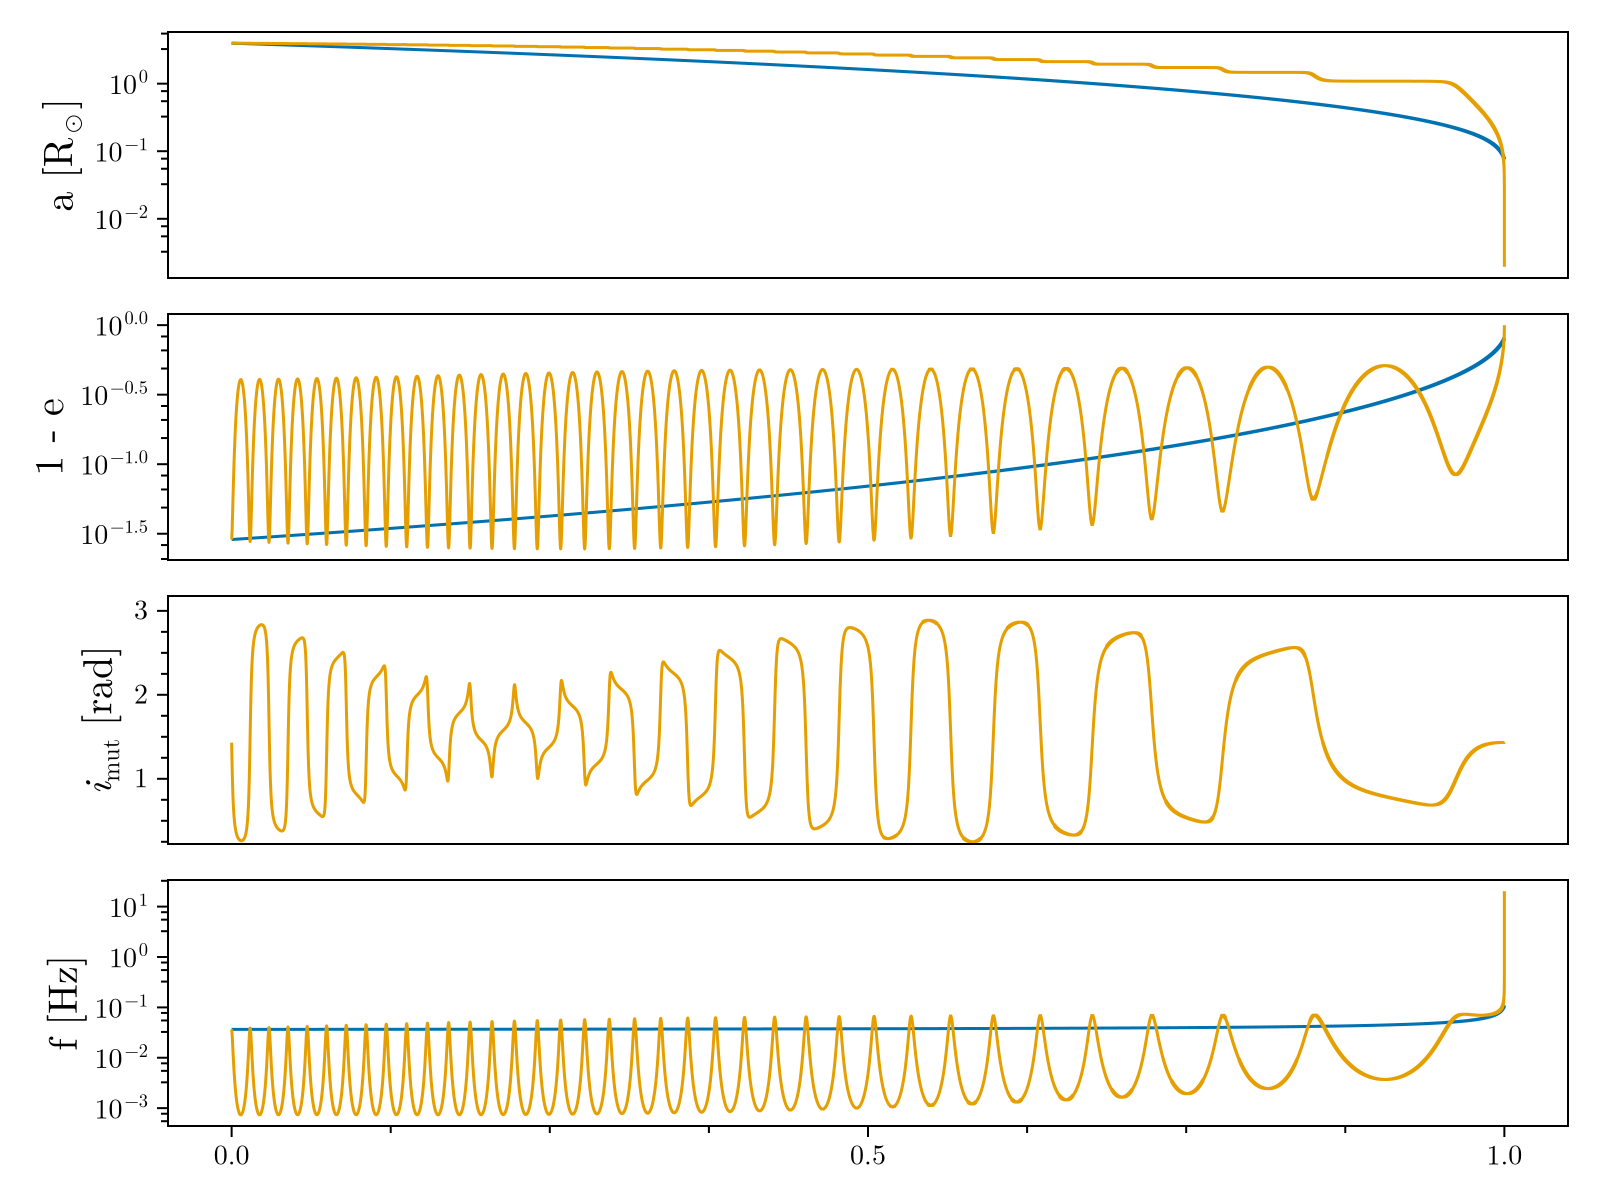

In [20]:
let ms = readdir("../data/evolution/GW_advanced_high_density_Z0005", join=true)
    filter!(x -> !contains(x, "_pert"), ms)
    println(ms[1])
    plot_evolution(ms[1], loge=true, loga=true) 
end

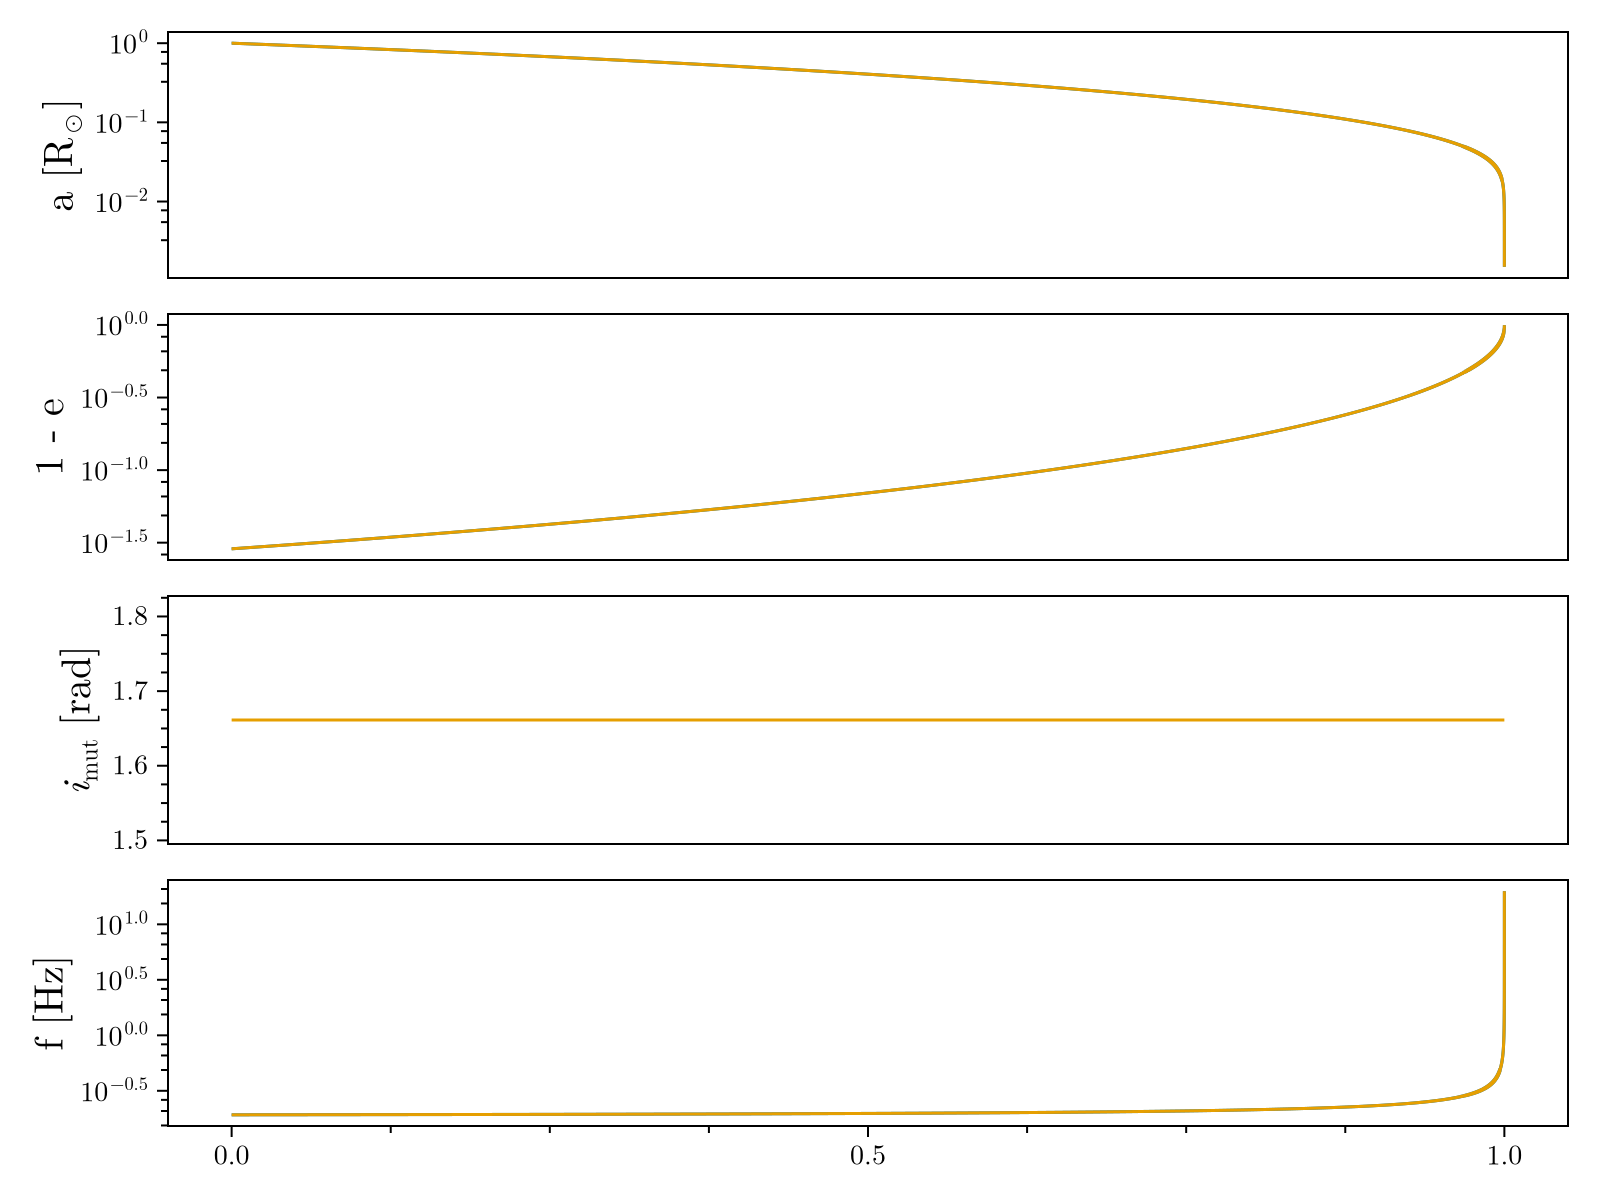

In [8]:
let ms = readdir("../data/evolution/triple-induced-mergers", join=true)
    filter!(x -> !contains(x, "_pert"), ms)
    plot_evolution(ms[2], loge=true, loga=true) 
end

# $\Delta t$ at different frequencies

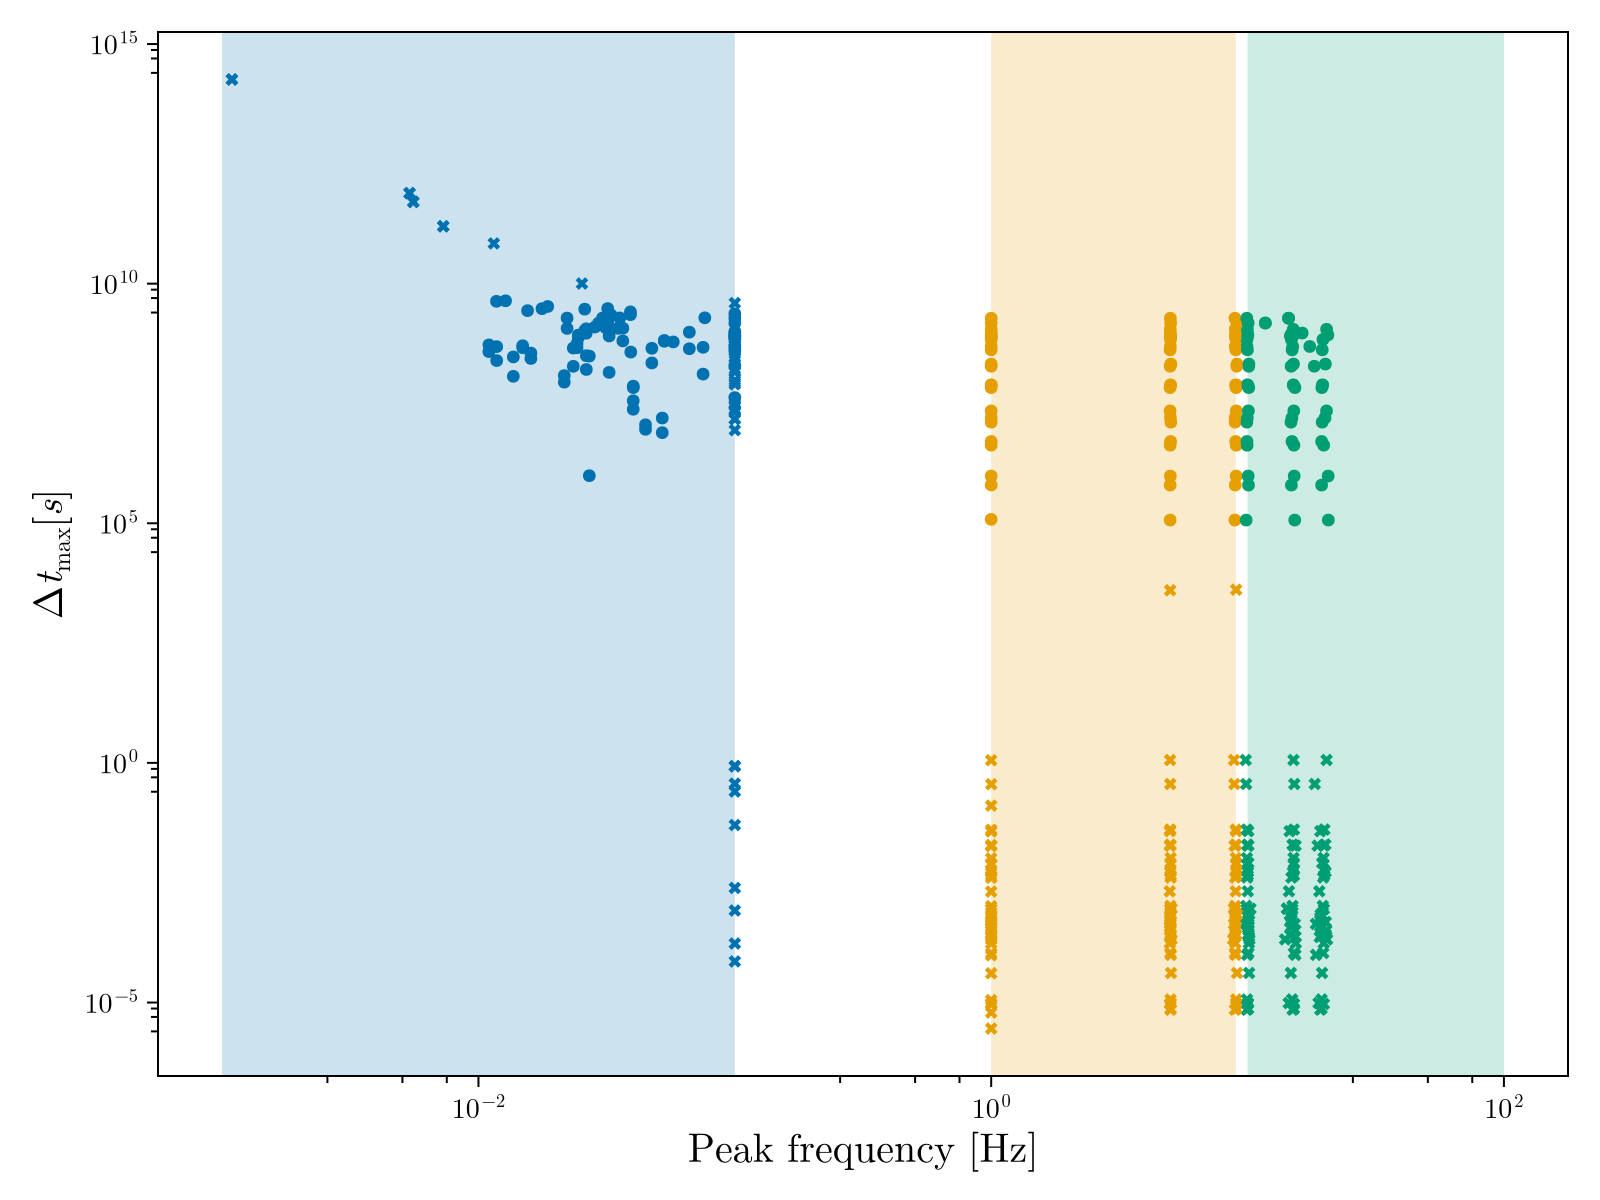

In [ ]:
let
    LISA_min, LISA_max = (1e-3, 0.1)
    ET_min, ET_max = (1, 10)
    LIGO_min, LIGO_max = (10, 100)

    colors = Makie.wong_colors()
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel="Peak frequency [Hz]", 
                         ylabel=L"\Delta t_\text{max} [s]",
                         xscale=log10, yscale=log10)
    vspan!(ax, LISA_min, LISA_max, color=(colors[1], 0.2))
    vspan!(ax, ET_min, ET_max, color=(colors[2], 0.2))
    vspan!(ax, LIGO_min, LIGO_max, color=(colors[3], 0.2))

    for data_dir in ("GW_advanced_high_density_Z0005", "triple-induced-mergers")
        marker = contains(data_dir, "triple-induced") ? :x : :circle
        files = readdir(joinpath(DATADIR, "evolution", data_dir), join=true)
        filter!(x -> !contains(x, "_pert"), files)
        for file in files
            file_pert = replace(file, ".csv" => "_pert.csv")

            data = CSV.File(file, select=["time_s", "fGW"])
            data_pert = CSV.File(file_pert, select=["time_s", "fGW"])

            t = data.time_s
            fGW = data.fGW

            t_pert = data_pert.time_s
            fGW_pert = data_pert.fGW

            LISA_ids = findall(x -> LISA_min < x < LISA_max, fGW)
            ET_ids = findall(x -> ET_min < x < ET_max, fGW)
            LIGO_ids = findall(x -> LIGO_min < x < LIGO_max, fGW)

            LISA_ids_pert = findall(x -> LISA_min < x < LISA_max, fGW_pert)
            ET_ids_pert = findall(x -> ET_min < x < ET_max, fGW_pert)
            LIGO_ids_pert = findall(x -> LIGO_min < x < LIGO_max, fGW_pert)

            if !iszero(LISA_ids) && !iszero(LISA_ids_pert)
                examples = (1e-3, 1e-2, 1e-1)
                for ex in examples
                    idx_min = argmin(abs.(fGW .- ex))
                    idx_min_pert = argmin(abs.(fGW_pert .- ex))

                    scatter!(ax, fGW[idx_min], abs(t[idx_min] - t_pert[idx_min_pert]), color=colors[1], marker=marker)
                end
            end

            
            if !iszero(ET_ids) && !iszero(ET_ids_pert)
                examples = (1, 5)
                for ex in examples
                    idx_min = argmin(abs.(fGW .- ex))
                    idx_min_pert = argmin(abs.(fGW_pert .- ex))

                    scatter!(ax, fGW[idx_min], abs(t[idx_min] - t_pert[idx_min_pert]), color=colors[2], marker=marker)
                end
            end

            if !iszero(LIGO_ids) && !iszero(LIGO_ids_pert)
                examples = (10, 15, 20)
                for ex in examples
                    idx_min = argmin(abs.(fGW .- ex))
                    idx_min_pert = argmin(abs.(fGW_pert .- ex))

                    scatter!(ax, fGW[idx_min], abs(t[idx_min] - t_pert[idx_min_pert]), color=colors[3], marker=marker)
                end
            end
        end
    end

    fig
end

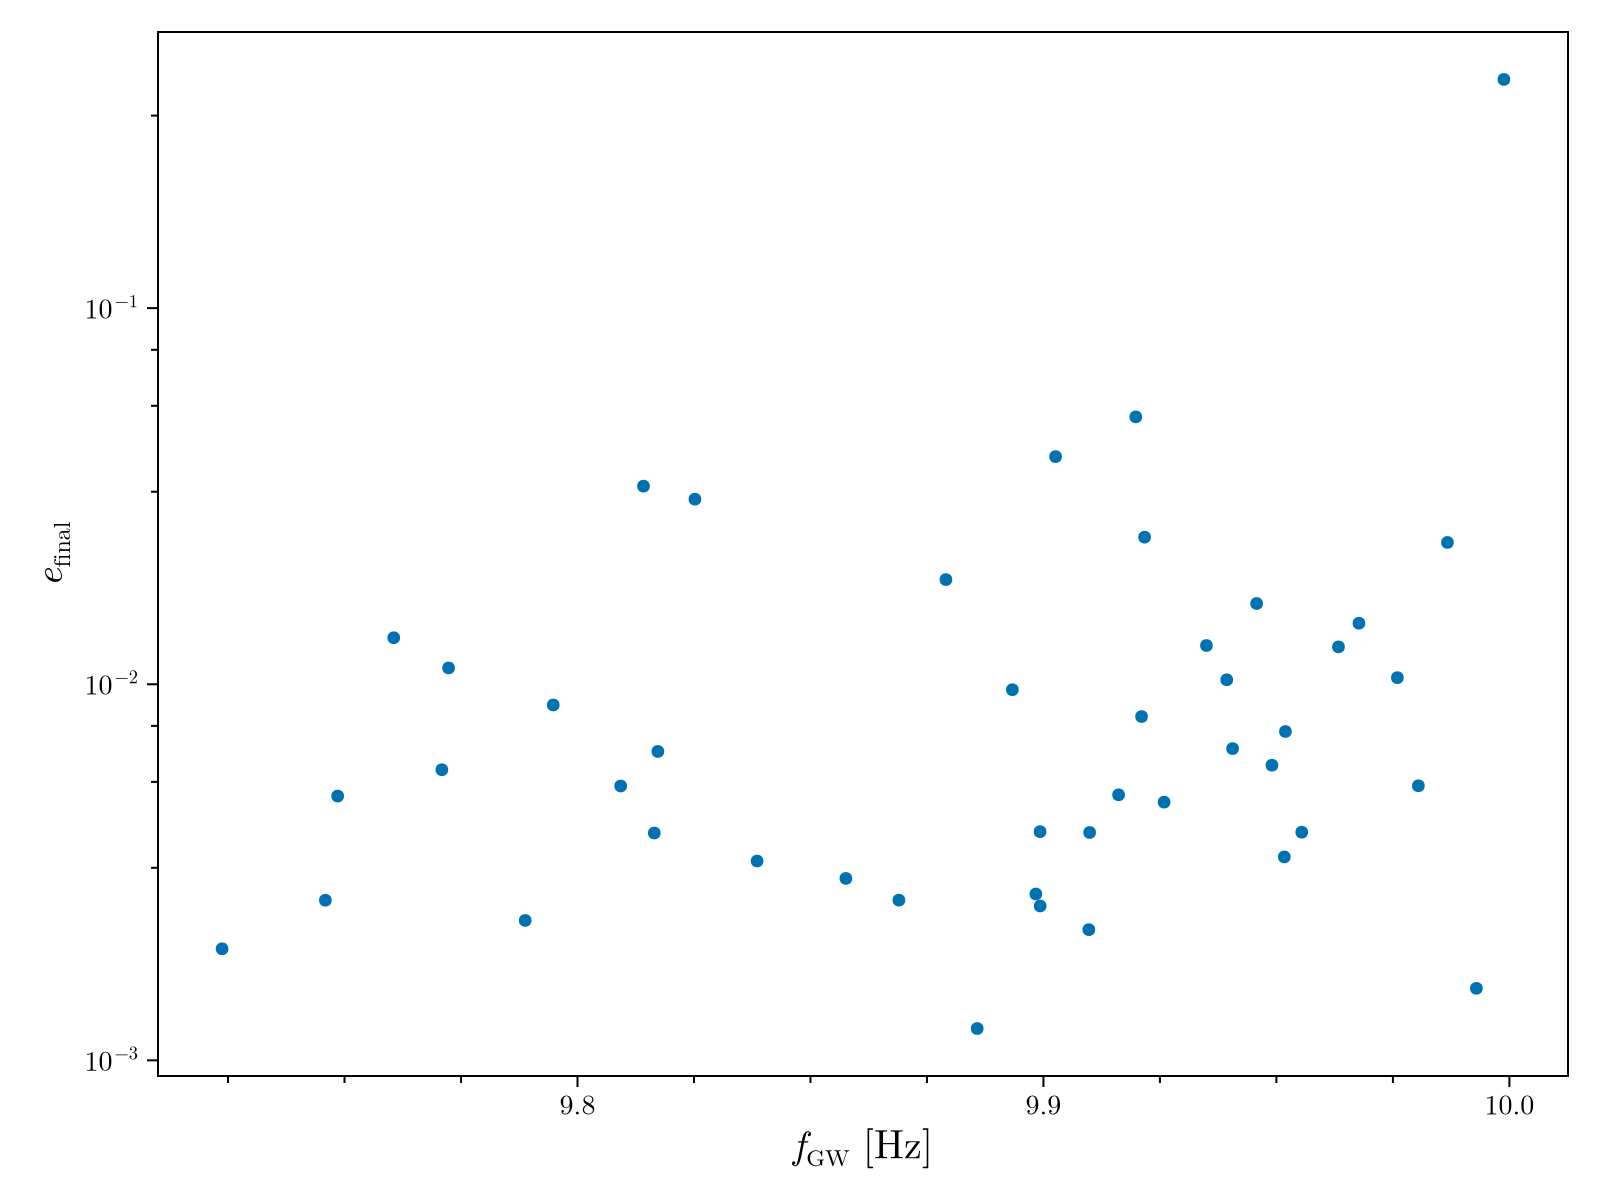

In [15]:
let
    data_dir = "GW_advanced_high_density_Z0005"
    files = readdir(joinpath(DATADIR, "evolution", data_dir), join=true)
    filter!(x -> !contains(x, "_pert"), files)
    colors = Makie.wong_colors()
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel=L"$f_\text{GW}$ [Hz]", ylabel=L"e_\text{final}", yscale=log10)

    for file in files
        file_pert = replace(file, ".csv" => "_pert.csv")

        data = CSV.File(file, select=["time_s", "fGW", "e"])
        data_pert = CSV.File(file_pert, select=["time_s", "fGW", "e"])

        t = data.time_s
        fGW = data.fGW

        t_pert = data_pert.time_s
        fGW_pert = data_pert.fGW

        if fGW_pert[end] > 8
            scatter!(ax, fGW_pert[end], data_pert.e[end], color=Makie.wong_colors()[1])
        end
    end
    fig
end

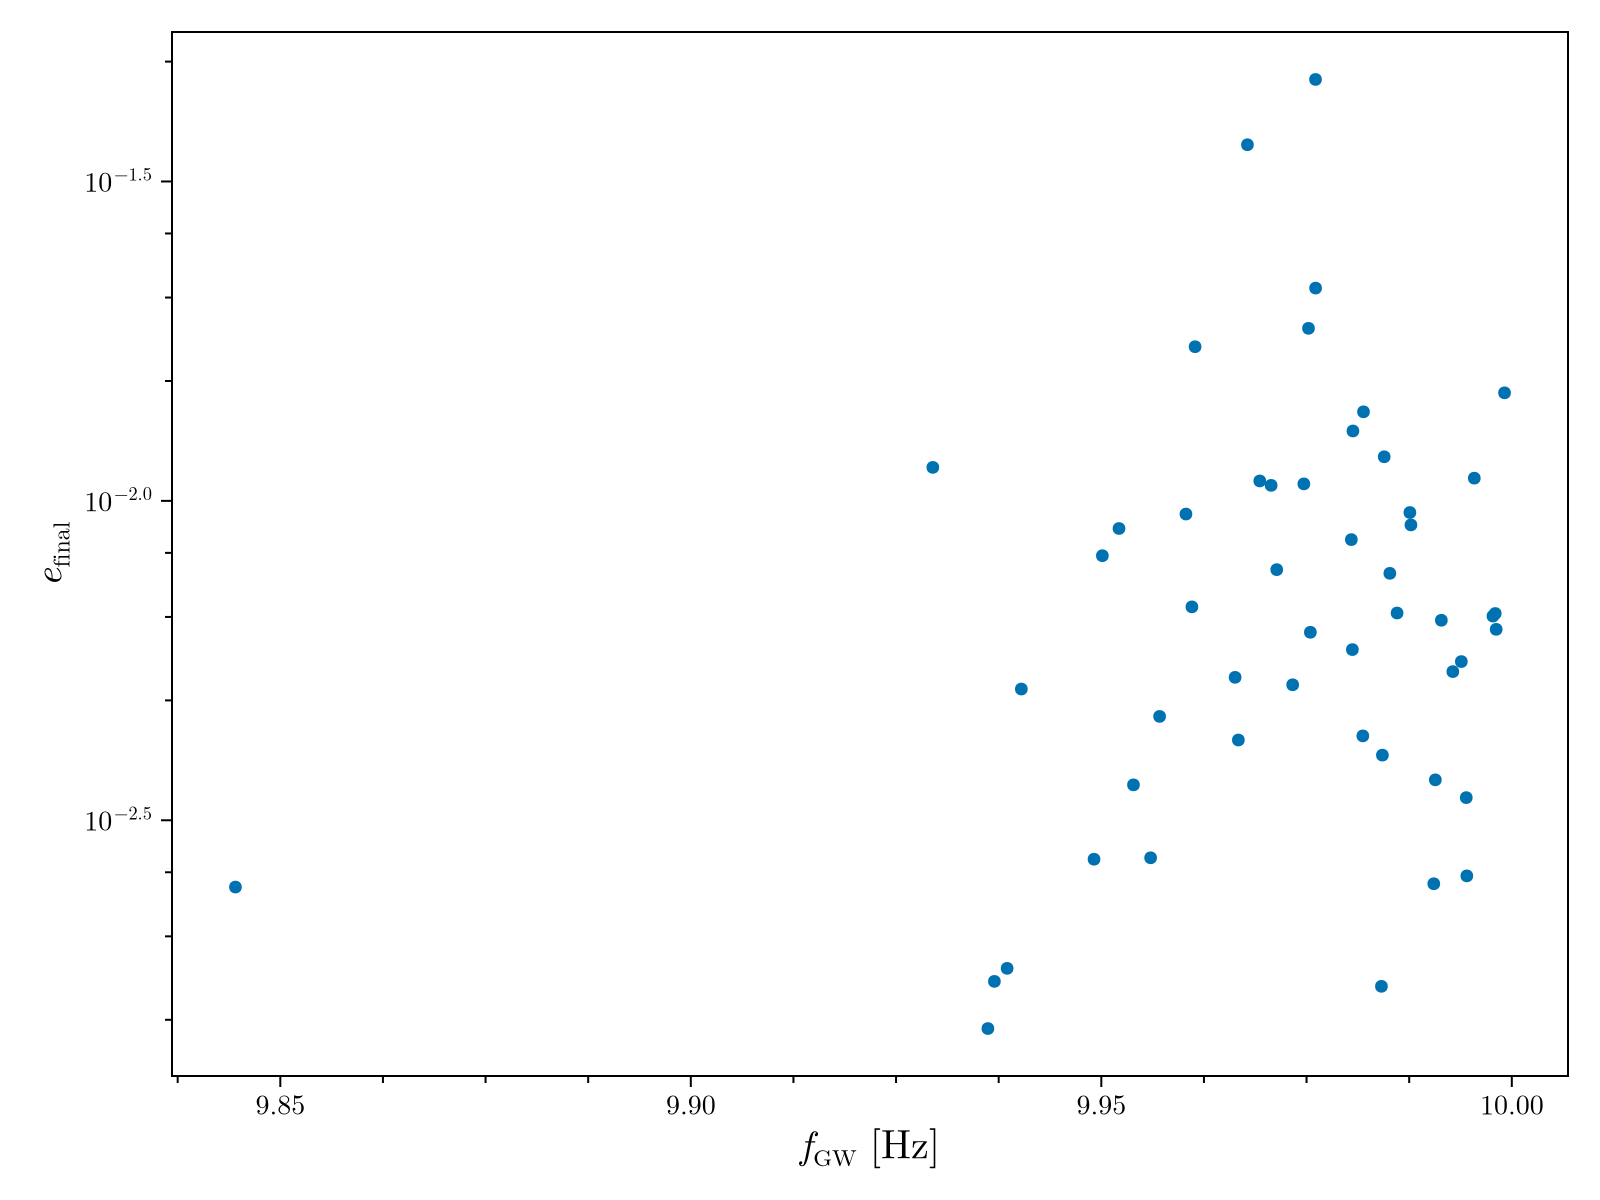

In [38]:
let
    data_dir = "triple_properties_of_merging_systems"
    files = readdir(joinpath(DATADIR, "evolution", data_dir), join=true)
    filter!(x -> !contains(x, "_pert"), files)
    colors = Makie.wong_colors()
    fig = Figure()
    ax = Axis(fig[1, 1], xlabel=L"$f_\text{GW}$ [Hz]", ylabel=L"e_\text{final}", yscale=log10)

    for file in files
        file_pert = replace(file, ".csv" => "_pert.csv")

        data = CSV.File(file, select=["time_s", "fGW", "e"])
        data_pert = CSV.File(file_pert, select=["time_s", "fGW", "e"])

        t = data.time_s
        fGW = data.fGW

        t_pert = data_pert.time_s
        fGW_pert = data_pert.fGW

        if fGW_pert[end] > 8
            scatter!(ax, fGW_pert[end], data_pert.e[end], color=Makie.wong_colors()[1])
        end
    end
    fig
end